# BEE 4750 Homework 2: Systems Modeling and Simulation

**Name**: Evan Wu

**ID**: 5839048

> **Due Date**
>
> Thursday, 09/25/25, 9:00pm

## Overview

### Instructions

-   Problem 1 asks you to draw a systems diagram and identify the type
    of a feedback.
-   Problem 2 asks you to model contaminant concentrations in a river
    and use simulation to compare the concentrations to a regulatory
    standard.
-   Problem 3 asks you to explore the implications of an ice-albedo
    feedback in the Earth’s climate system by understanding the
    equilibria of the modeled system and their stabilities.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `c:\Users\evant\OneDrive\Documents\GitHub\hw2-etw`


In [2]:
using Plots
using LaTeXStrings
using CSV
using DataFrames
using Roots

## Problems (Total: 30 Points)

### Problem 1 (5 points)

Draw a systems diagram for the relationship between global mean
temperature, atmospheric CO<sub>2</sub> concentrations, and ocean
CO<sub>2</sub> concentrations. What are the signs of the interactions
between these components and why? What does this suggest about the
overall feedback between temperature and the ocean carbon cycle?

> **Tip**
>
> Think about Henry’s law for CO<sub>2</sub>.


<img src="p1.png">

Atmospheric CO<sub>2</sub>:
- Increased atmospheric CO<sub>2</sub> concentrations results in increased global mean temperature. This is because increased CO<sub>2</sub> levels helps trap heat from leaving the Earth.

- Can be decreased by the ocean absorbing CO<sub>2</sub>. This is possible by the ocean absorbing CO<sub>2</sub> when it dissolves into the water to be used by plankton for photosynthesis, until they die. Dead plankton would then sink into the ocean floor and effectively drag carbon down with them.

Ocean CO<sub>2</sub>:
- Increased by taking CO<sub>2</sub> from the atmosphere. Mentioned previously above. 

- Can be decreased by higher global temperatures as it can be harder to absorb CO<sub>2</sub>. Higher global temperatures means water becomes hotter, making it less soluble in capturing CO<sub>2</sub>.

Global mean temperature:
- Increased by larger atmospheric CO<sub>2</sub> concentrations due to less heat being radiated out to space from CO2 abundance.

This suggests that the feedback between temperature and the ocean carbon cycle is very delicate and can be easily amplified for the detriment of society. If the atmospheric carbon dioxide levels gets too high from emissions, global temperatures may rise too much that the ocean becomes ineffective at capturing carbon from the atmosphere, further worsening global temperature and atmospheric CO<sub>2</sub> levels.


### Problem 2 (15 points)

A river which flows at 10 km/d is receiving discharges of wastewater
contaminated with CRUD from two sources which are 15 km apart, as shown
in the Figure below. CRUD decays exponentially in the river at a rate of
0.36 $\mathrm{d}^{-1}$ and is deposited by the atmosphere along the
river at a rate of 54 kg/km/d. 

<figure>
<img src="attachment:figures/river_diagram.png"
alt="Schematic of the river system in Problem 2" />
<figcaption aria-hidden="true">Schematic of the river system in Problem
2</figcaption>
</figure>

#### Problem 2.1

Draw a systems diagram with the relevant control volume(s) denoted and
any relevant in/out-flows between these boxes. How did you decide how
many boxes were needed?

<img src="p2.png">


This diagram is built on the following assumptions:
- Box/Control Volume 1 occurs when the river and Stream 1 immediately mix
- System is in steady state
- No additional accumulation/consumption besides CRUD decay along the river and CRUD deposited by the atmosphere

It was decided to include two boxes for control volumes in this system diagram. The first box is for when the river and Stream 1 mix. The second box is to account for not only the mixing of the river intermediate stream and Stream 2, but also any CRUD added by the atmosphere or decayed along the intermediate between System 1 and System 2, as well as the outlet after System 2. One box would not be sufficient to capture the change in CRUD along the river, and there is no additional discharges to justify adding more boxes.

#### Problem 2.2

Develop a model for the concentration of CRUD downriver by formulating
and solving the appropriate differential equation(s) analytically.


> **Tip**
>
> Formulate your model in terms of distance downriver, rather than
> leaving it in terms of time from discharge.

Known:
- River flow velocity: 10 km d^-1
- Decay along the river: 0.36 d^-1
- Deposit by atmosphere: 54 kg/(km d)
- River volumetric flow rate: 250,000 m^3/d
- River water density:  0.5kg/(1000 m^3)
- Distance from Stream 1 to Stream 2: 15km
- Stream 1 incoming volumetric flow rate (Stream closer to river inflow): 40,000 m^3/d
- Stream 1 CRUD density: 9 kg/(1000m^3)
- Stream 2 incoming volumetric flow rate (Stream further from river inflow): 60,000 m^3/d
- Stream 2 CRUD density: 7 kg/(1000m^3)

The model of CRUD downriver can be divided into two sections: the distance in between where Stream 1 and Stream 2 are discharged and the river after Stream 2 is discharged. This can be analyzed by creating differential equations based on the rate of decay and deposition from the atmosphere:



Let U = river velocity in km/d, x is the distance downstream in km, and $C(x)$ is the concentration of CRUD at x in kg/km

$$ U \frac{dC}{dx} = \Delta CRUD $$

$$ U \frac{dC}{dx} = - Decay + Atmospheric deposit $$

Decay:
- Decay constant (k) is 0.36 d^-1, decay is based on the amount of CRUD in the river
- For simplification purposes, the decay will be based on the initial concentration of CRUD coming from Stream 1, rather than continually considering CRUD added from the atmospheric deposit. In reality, this decay factor would be larger as CRUD is continually added.
$$ \frac{dM}{dt} = -kM $$
- Integrating the equation, and expressing time as distance over the river's velocity:
$$ M = M_0e^{-kt} = 36e^{-\frac{kx}{U}}$$
- The corresponding decay rate would be:
$$ -kM = -36ke^{-\frac{kx}{U}} = -12.96e^{-\frac{kx}{10}}$$

Atmospheric deposit:
- Atmospheric deposit rate is independent of CRUD in the river:
$$ A = 54 \frac{kg}{km \bullet d} \times \frac{x}{U} $$

Finding the river intermediate concentration:
- Provided the known rates of change, the river intermediate coming into Box 2 can be expressed:
$$ U \frac{dC_1}{dx} = - 12.96e^{-\frac{0.36x}{10}} + 54\frac{x}{U} $$
- As $U = 10 \frac{km}{d}$, it can be removed from the left-hand side:
$$ 10 \frac{dC_1}{dx} = - 12.96e^{-\frac{0.36x}{10}} + 54\frac{x}{10} $$
$$ \frac{dC_1}{dx} = - 1.296e^{-\frac{0.36x}{10}} + 0.54x $$
- Integrating this equation in terms of x:
$$ C_1(x) = 36e^{−0.36x / 10} + 0.27 x² + C_0 $$
- $C_0$ can be solved by setting the initial condition that $C_1(x=0)$ is equal to the amount of CRUD from Stream 1 added

Inlet stream:
- Stream 1 CRUD flowrate: 

$$ \dot{m_a}\rho_a = 40,000 \frac{m^3}{d} \times 9 \frac{kg}{1000m^3} = 360 \frac{kg}{d} \div 10 \frac{km}{d} = 36 \frac{kg}{km} $$
$$ 36 = 36e^{0} + 0 + C_0 $$
$$ C_0 = 0 $$
- The differential equation would be:
$$ C_1(x) = 36e^{−0.36x / 10} + 0.27 x² $$

Next, we can consider the differential equation for the river outlet after Stream 2 is mixed in:

$$ U \frac{dC_2}{dx} = - Decay + Atmospheric deposit $$

Decay:
- Decay constant (k) is 0.36 d^-1, decay is based on the amount of CRUD in the river intermediate
- For simplification purposes, the decay will be the sum of the initial concentration of CRUD mixed from the river intermediate and Stream 2
$$ \frac{dM}{dt} = -kM $$
- Integrating the equation:
$$ M = M_0e^{-kt} = M_0e^{-k\frac{x}{U}} $$

$M_0$ = Sum of initial CRUD in river intermediate and Stream 2
- Stream 2 CRUD flow rate:
$$ \dot{m_a} \rho_a =  60,000 \frac{m^3}{d} \times 7 \frac{kg}{1000m^3} = 420 \frac{kg}{d} \div 10 \frac{km}{d} = 42 \frac{kg}{km}$$
- To find the concentration of CRUD mixed in with the river intermediate, $C_1(x=15)$ must be calculated:
$$ C_1(x=15) = 36e^{-0.36 \times 15 / 10} + 0.27(15)^2 = 81.7 $$
- The corresponding decay rate would be:
$$ M = 123.7e^{-k\frac{x}{U}} $$
$$ -kM = -123.7ke^{-\frac{x}{U}} = -44.53e^{-k\frac{x}{10}}$$

Atmospheric deposit:
- Atmospheric deposit rate is independent of CRUD in the river
$$ A = 54 \frac{kg}{km \bullet d} \times \frac{x}{U} $$

Decay and deposit equations can be plugged into the differential equation for the river outlet coming out of System 2:

$$ U \frac{dC_2}{dx} = -44.53e^{-0.36\frac{x}{10}} + 54 \frac{x}{U} $$
- As U = 10:
$$ \frac{dC_2}{dx} = -4.453e^{-0.36\frac{x}{10}} + 0.54(x) $$
- Integrating this equation:
$$ C_2(x) = 123.7e^{-0.036x} + 0.27x^2 + C_0 $$
- Since System 2 occurs 15km after System 1, x must be subtracted by 15.
$$ C_2(x) = 123.7e^{-0.036(x-15)} + 0.27(x-15)^2 + C_0 $$
- The constant of integration can be found by establishing the initial condition of $C_2$ when the river intermediate mixes with Stream 2 at $x = 15km$
$$ C_2(x=15) = 123.7$$
$$ 123.7 = 123.7e^0  + C_0$$
$$ C_0 = 0 $$

Therefore, the equation for $C_2(x)$ would be:
$$ C_2(x) = 123.7e^{-0.036(x-15)} + 0.27(x-15)^2 $$

The two differential equations for concentration in kg/km after System 1 and System 2 would be:

$$C_1(x) = 36e^{−0.36x / 10} + 0.27 x² $$
$$C_2(x) = 123.7e^{-0.036(x-15)} + 0.27(x-15)^2 $$

#### Problem 2.3

Determine if the system in compliance with a regulatory limit of
$2.3\ \text{kg}/(1000 \text{m}^3)$. You can do this analytically or
computationally.

To convert $\frac{kg}{km}$ to $\frac{kg}{1000m^3}$, the mass flow rates in both systems must be considered:

Known:
- River flow velocity: 
$$10 \frac{km}{d}$$
- River volumetric flow rate: 
$$250,000 \frac{m^3}{d}$$
- Stream 1 incoming volumetric flow rate (Stream closer to river inflow): 
$$40,000 \frac{m^3}{d}$$
- Stream 2 incoming volumetric flow rate (Stream further from river inflow): 
$$60,000 \frac{m^3}{d}$$

System 1:
$$\dot{m_2} = \dot{m_1} + \dot{m_a}$$
$$\dot{m_2} = (250,000 + 40,000) \frac{m^3}{d} = 290,000 \frac{m^3}{d}$$

System 2:
$$\dot{m_3} = \dot{m_2} + \dot{m_b}$$
$$\dot{m_3} = (290,000 + 60,000) \frac{m^3}{d} = 350,000 \frac{m^3}{d}$$

When considering the river's velocity U:

System 1:

$$ 10 \frac{km}{d} \div 290,000 \frac{m^3}{d} = \frac{1}{29000} \frac{km}{m^3} = \frac{1}{29} \frac{km}{1000m^3}$$

System 2: 

$$ 10 \frac{km}{d} \div 350,000 \frac{m^3}{d} = \frac{1}{35000} \frac{km}{m^3} = \frac{1}{35} \frac{km}{1000m^3}$$

To determine if the system is in compliance with the regulatory limit, the concentration of CRUD in kg/1000m^3 will be plotted over distance down the river based on the two equations created in Problem 3.2. A range of distance values is sampled from 0 to 30 in increments of 0.3. This generates 100 samples, with 15km as the midpoint when Stream 2 is added into the river. The calculations are conducted through a for loop, utilizing the relevant equation based on the distance downstream. A red dotted line is drawn at concentration = 2.3 kg/1000m^3 to observe any values that satisfy the regulations.

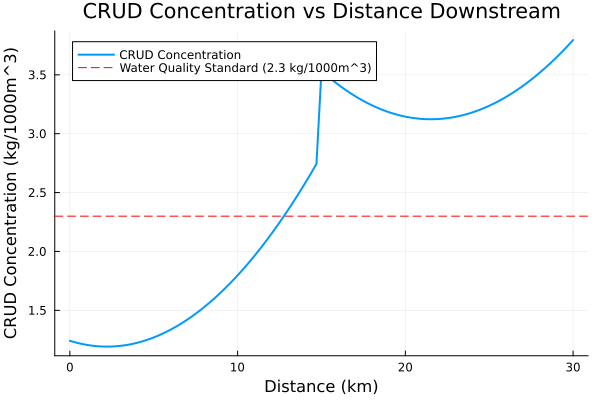

In [3]:
distance = [0:0.3:30;]
conc = [];
S1 = 1/29; # conversion factor to kg/1000m^3 for system 1
S2 = 1/35; # conversion factor to kg/1000m^3 for system 2

for x in distance
    if x < 15
        C1 = 36*exp(-0.36*x/10) + 0.27*x^2
        C1 = C1*S1
        push!(conc, C1)
    else
        C2 = 123.7*exp(-0.036*(x-15)) + 0.27*(x-15)^2
        C2 = C2*S2
        push!(conc, C2)
    end
end

# print(conc) # print concentrations for value verification 
plot(distance, conc, xlabel = "Distance (km)", ylabel = "CRUD Concentration (kg/1000m^3)", title = "CRUD Concentration vs Distance Downstream", legend = true, label = "CRUD Concentration", lw = 2)
hline!([2.3], linestyle = :dash, color = :red, label = "Water Quality Standard (2.3 kg/1000m^3)")

Caption: Distance downstream in km vs CRUD concentration in $kg/1000m^3$ from 0 to 30 km. 

Based on this plot, the system only meets regulations from 0 km to approximately 13km. This can be explained because as distance increases, the rate of CRUD lost to decay decreases while the rate of CRUD gained from the atmosphere remains constant. Therefore, eventually there will be a point where CRUD concentration will continually increase, evident by the minimum stationary points observed. Due to the assumption made where the decay is solely based on the initial CRUD at the system, realistically the decay factor would have a larger magnitude, meaning that the CRUD concentrations would probably be satisfied until x = 15 when Stream 2 is added.

### Problem 3 (10 points)

In class, we discussed the ice-albedo feedback and its possible
influence on melting the hypothesized [“Snowball
Earth”](https://en.wikipedia.org/wiki/Snowball_Earth). In this problem,
we’ll introduce a simple model of the Earth’s energy balance with
includes this feedback and examine the stability of the climate.

This simple model of the energy balance (averaged over the entire
planet) is:

<span id="eq-climate">$$
\underbrace{C\frac{dT}{dt}}_{\text{change in heat}} = \underbrace{\frac{(1-\alpha)S}{4}}_{\text{incoming radiation}} - \underbrace{(A - BT)}_{\text{outgoing radiation}} + \underbrace{a\ln \left(\frac{[CO_2]}{[CO_2]_{PI}}\right)}_{\text{greenhouse effect}},
 \qquad(1)$$</span>

where:

-   $T$ is the Earth’s global mean temperature (in $^\circ\text{C}$);
-   $C$ is the heat capacity of the atmosphere and shallow ocean, taken
    to be $51\ \text{J}/\text{m}^2/^\circ\text{C}$;
-   $\alpha$ is the planetary albedo, or the fraction of incoming
    radiation reflected by the Earth, which has a present-day value of
    approximately 0.3;
-   $S$ is the solar constant, or the amount of solar radiation received
    by the Earth averaged over area, which has a present-day value of
    $1368\ \text{W}/\text{m}^2$ but during the Neoproteorozoic Era had a
    value of $1272\ \text{W}/\text{m}^2$ (this is divided by four
    because the Earth is a sphere but $S$ is the radiation captured by a
    disc with radius equal to that of the Earth);
-   $A$ and $B$ are coefficients from the linearization of outgoing
    radiation physics, and have corresponding values
    $B=-1.3\ \text{W}/\text{m}^2/^\circ\text{C}$ (estimated from a
    number of lines of evidence about the sensitivity of outgoing
    radiation to temperature; this is negative due to a sign convention
    about the direction of incoming vs. outgoing radiation) and
    $A=221.2\ \text{W}/\text{m}^2$ (estimated by assuming the
    pre-industrial temperature of $14^\circ\text{C}$ was stable without
    anthropogenic greenhouse gas emissions).

We will ignore the greenhouse effect term as we are considering the
Earth system well before humans were around.

#### Problem 3.1

Discretize the climate model
(<a href="#eq-climate" class="quarto-xref">Equation 1</a>) using forward
Euler integration and a time step of $\Delta t = 1$ yr.

<span id="eq-climate">$$
{C\frac{dT}{dt}} = {\frac{(1-\alpha)S}{4}} - {(A - BT)}$$</span>

Divide both sides by C:

<span id="eq-climate">$$
{\frac{dT}{dt}} = \frac{1}{C}({\frac{(1-\alpha)S}{4}} - {(A - BT)})$$</span>

Provided that $$ \frac{dT}{dt} \approx \frac{T(t+\triangle t - T(t))}{\triangle t} $$:

<span id="eq-climate">$$
{\frac{T(t + \triangle t) - T(t)}{\triangle t}} = \frac{1}{C}({\frac{(1-\alpha)S}{4}} - {(A - BT(t))})$$</span>

Rearrange to make $T(t+\Delta t)$ the subject:

<span id="eq-climate">$$
T(t + \triangle t) - T(t) = \frac{\triangle t}{C}({\frac{(1-\alpha)S}{4}} - A + BT(t))$$</span>

<span id="eq-climate">$$
T(t + \triangle t) = T(t) + \frac{\triangle t}{C}({\frac{(1-\alpha)S}{4}} - A + BT(t))$$</span>

Let $\triangle t=1$ year:

<span id="eq-climate">$$
T(t + 1) = T(t) + \frac{1}{C}({\frac{(1-\alpha)S}{4}} - A + BT(t))$$</span>

#### Problem 3.2

Rather than assuming a constant value for the albedo $\alpha$, we will
represent the ice-albedo feedback by letting $\alpha$ depend on $T$:

$$\alpha(T) = 
    \begin{cases} 
        \alpha_i & \quad \text{if } T \leq -10^\circ \text{C} \\
        \alpha_i + (\alpha_0 - \alpha_i)((T+10) / 20) & \quad \text{if } -10^\circ \text{C} \leq T \leq 10^\circ \text{C} \\
        \alpha_0 & \quad \text{if } T \geq 10^\circ \text{C}.
    \end{cases}$$

Let $\alpha_i = 0.5$ and $\alpha_0 = 0.3$. Simulate the simple climate
model using the Neoprotereozoic value of $S$ with temperature-varying
albedo for initial values of $T$ spanning
$-60^\circ\text{C} \leq T_0 \leq 30^\circ\text{C}$ over a period of 200
years. Plot the temperature trajectories. How many equilibria are there
and what are their stabilities?

Have to consider three scenarios for the climate model based on the conditions where albedo is different. 

For $ T\leq-10^oC $:

$\alpha (T)=\alpha_i=0.5$

Simple climate model from $-60^oC\leq T\leq-10^oC$:

<span id="eq-climate">$$
T(t + 1) = T(t) + \frac{1}{C}({\frac{(1-0.5)S}{4}} - A + BT(t))$$</span>

<span id="eq-climate">$$
T(t + 1) = T(t) + \frac{1}{C}({\frac{0.5S}{4}} - A + BT(t))$$</span>

For $ T\geq10^oC $:

$\alpha(T)=\alpha_0=0.3$

Simple climate model from $ 10^oC\leq T\leq30^oC$:

<span id="eq-climate">$$
T(t + 1) = T(t) + \frac{1}{C}({\frac{(1-0.3)S}{4}} - A + BT(t))$$</span>

<span id="eq-climate">$$
T(t + 1) = T(t) + \frac{1}{C}({\frac{0.7S}{4}} - A + BT(t))$$</span>

For $-10^oC\leq T\leq10^oC$:

$\alpha(T)=\alpha_i+(\alpha_0-\alpha_i)((T+10)/20)$

For $\alpha_i = 0.5,\alpha_0 = 0.3$:

$\alpha(T)=0.5+(0.3-0.5)((T+10)/20)$

$\alpha(T) =0.5-0.01(T+10)=0.4-0.01T$

Simple climate model from $-10^oC\leq T\leq10^oC$:

<span id="eq-climate">$$
T(t + 1) = T(t) + \frac{1}{C}({\frac{(1-(0.4 - 0.01T))S}{4}} - A + BT(t))$$</span>

<span id="eq-climate">$$
T(t + 1) = T(t) + \frac{1}{C}({\frac{(0.6 + 0.01T(t))S}{4}} - A + BT(t))$$</span>

Now that there are mathematical equations for what the differential equation would look under different temperatures, two functions can be created to calculate the value of the equation's time step and $T(t+1)$. The simulate_timestep function is coded to use different albedo values depending on the current temperature of the system. The simulate_climate function creates an empty array of temperature values to be stored later and runs a for loop to create future T values based on the current temperature and the provided constants. The loop is ran for as many times as the total duration divided by $\Delta t$.

In scenarios where T = $10^oC$ or $-10^oC$, the equation where albedo is dependent on temperature would be given priority over the static albedo values. While this is a small nitpick, it may have effects on the system as a whole.

In [4]:
function simulate_timestep(T, B, C, alpha, S, A)
    if T <= -10 && T >= 10
        alpha = 0.4 - 0.01 * T
    elseif T > 10
        alpha = 0.3
    else
        alpha = 0.5
    end
    return (S * (1 - alpha) / 4 - A + B * T) / C
end

function simulate_climate(T0, B, C, alpha, S, A, time, dt)
    steps = Int64(time / dt)
    T = zeros(steps + 1)
    T[1] = T0    
    for i in 1:steps
        T[i+1] = T[i] + simulate_timestep(T[i], B, C, alpha, S, A) * dt
    end
    return T
end

simulate_climate (generic function with 1 method)

The numerical constants in the equation can be plugged into the two functions. A range for the different temperatures sampled is created. The step increase for each temperature is selected to be +5 as it provides sufficient samples to witness how varying albedo affects global temperature over time. An empty array called real_dataset is generated to store future temperature values. 

To trial each temperature value, a for loop is used to model the differential equation based on the initial temperature and numerical constants. In the loop, there is a check to determine which albedo value is used according to the initial temperature. 

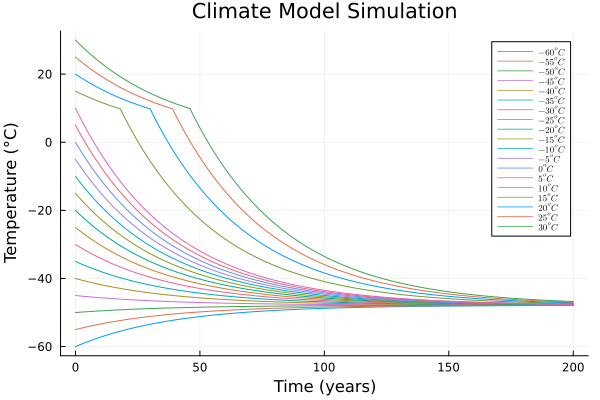

In [5]:
# Constants
B = -1.3 # W/m^2/°C
C = 51 # J / m^2 / °C
S  = 1272 # W/m^2 (solar constant during Neoprotereozoic era) 
A = 221.2 # W/m^2
time = 200.0 # years
dt = 1.0 # years

temperature_range = [-60, -55, -50, -45, -40, -35, -30, -25, -20, -15, -10, -5, 0, 5, 10, 15, 20, 25, 30]; # Initial temperatures from -60°C to 30°C
real_dataset = []; # To store the results

for T in temperature_range # Loop over initial temperatures
    if T <= -10
        alpha = 0.5
        final_data = simulate_climate(T, B, C, alpha, S, A, time, dt)
        push!(real_dataset, final_data)
    elseif T > -10 && T < 10
        alpha = 0.4 - 0.01 * T
        final_data = simulate_climate(T, B, C, alpha, S, A, time, dt)
        push!(real_dataset, final_data)
    else
        alpha = 0.3
        final_data = simulate_climate(T, B, C, alpha, S, A, time, dt)
        push!(real_dataset, final_data)
    end
end

# print(real_dataset) ; used to check final value at equilibrium, commented to avoid cluttering the output

plot(0:dt:time, real_dataset, xlabel="Time (years)", ylabel="Temperature (°C)", title="Climate Model Simulation",
label = [L"$-60^o C$" L"$-55^o C$" L"$-50^o C$" L"$-45^o C$" L"$-40^o C$" L"$-35^o C$" L"$-30^o C$" L"$-25^o C$" L"$-20^o C$" L"$-15^o C$" L"$-10^o C$" L"$-5^o C$" L"$0^o C$" L"$5^o C$" L"$10^o C$" L"$15^o C$" L"$20^o C$" L"$25^o C$" L"$30^o C$"
], legend=:best, legendfontsize=6)

Caption: Climate model simulation for Earth's global temperature change over 200 years with starting temperatures from $[-60^oC,30^oC]$ with $S=1272\frac{W}{m^2}$ 

In this graph, there is only one equilibrium state. All initial temperature numbers stabilize into a constant value at $-46.7^oC$. This value is confirmed through read the last number printed in the real_dataset variable. Although all initial temperatures converge to this number, some temperatures have different trajectories due to undergoing changes in albedo. This is especially apparent with temperatures above $10^oC$ as they go through more variance in albedo values than other temperatures.  

#### Problem 3.3

One might hypothesize that one cause for the transition from Snowball
Earth (the stable frozen equilibrium from Problem 3.2) was an increasing
amount of incoming solar radiation (as expressed by an increase in $S$).
Examine this hypothesis using our simple model. Is this factor enough to
cause the planet to warm to the pre-industrial temperature of
$14^\circ\text{C}$?

In this scenario, the incoming solar radiation is increased to its current solar constant at $1361\frac{W}{m^2}$. Otherwise, we keep the other numerical constants, range of tested temperatures, and the code functionalities exactly as it was in Problem 3.2. 

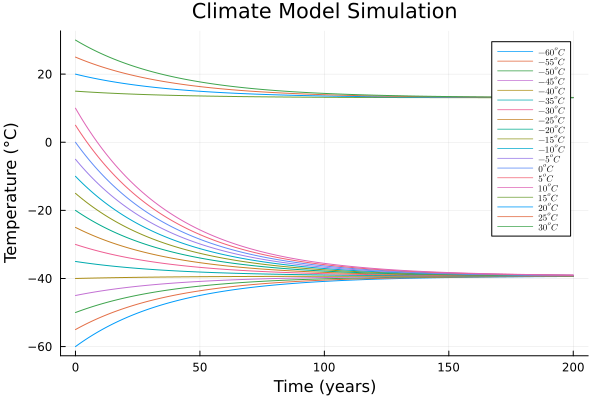

In [6]:
temperature_range = [-60, -55, -50, -45, -40, -35, -30, -25, -20, -15, -10, -5, 0, 5, 10, 15, 20, 25, 30];
real_dataset2 = [];

S = 1361 # W/m^2 (current solar constant)

for T in temperature_range
    if T <= -10
        alpha = 0.5
        final_data = simulate_climate(T, B, C, alpha, S, A, time, dt)
        push!(real_dataset2, final_data)
    elseif T > -10 && T < 10
        alpha = 0.4 - 0.01 * T
        final_data = simulate_climate(T, B, C, alpha, S, A, time, dt)
        push!(real_dataset2, final_data)
    else
        alpha = 0.3
        final_data = simulate_climate(T, B, C, alpha, S, A, time, dt)
        push!(real_dataset2, final_data)
    end
end

# print(real_dataset2) # used to check final values at equilibrium, commented to avoid cluttering the output

plot(0:dt:time, real_dataset2, xlabel="Time (years)", ylabel="Temperature (°C)", title="Climate Model Simulation",
label = [L"$-60^o C$" L"$-55^o C$" L"$-50^o C$" L"$-45^o C$" L"$-40^o C$" L"$-35^o C$" L"$-30^o C$" L"$-25^o C$" L"$-20^o C$" L"$-15^o C$" L"$-10^o C$" L"$-5^o C$" L"$0^o C$" L"$5^o C$" L"$10^o C$" L"$15^o C$" L"$20^o C$" L"$25^o C$" L"$30^o C$"
], legend=:best, legendfontsize=6) 

Caption: Climate model simulation for Earth's global temperature change over 200 years with starting temperatures from $[-60^oC,30^oC]$ with $S=1362\frac{W}{m^2}$

For this simulation, there is a significant difference where a second equilibrium state occurs when temperatures above $10^oC$ stabilize at $13^oC$. Additionally, the previous equilibrium state in Problem 3.2 stabilizes at $-39.4^oC$ now. The existence of this second equilibrium in this model is enough to validate the hypothesis that increased solar radiation is enough to warm the planet to pre-industrial temperatures if the initial temperature is hot enough.

## References

List any external references consulted, including classmates.

Week 4.1 Lecture Slides: Simulation Models

Week 4.2 Lecture Slides: Dissolved Oxygen

Generative AI has been used to cross examine workings and methodologies.